# Сдвиг частоты в четырёхпучковой скомпенсированной схеме

## Условие задачи

В четырёхпучковой скомпенсированной схеме два пучка с одной стороны имеют смещения $\pm a$.
Считая поперечные сечения пучков круглыми, а радиальную зависимость плотности гауссовой, требуется в первом приближении теории возмущений рассчитать зависимость сдвига частоты для частицы слабого сгустка от смещения $a$.

## Модель

В четырёхпучковой скомпенсированной схеме воздействие основного встречного пучка на частицу слабого сгустка компенсируется пучком противоположного знака заряда.
При $a = 0$ пучки перекрываются, их заряды компенсируют друг друга, и сдвиг частоты равен нулю.
При $a \neq 0$ компенсация нарушается.

Рассматривается центральный пучок, расположенный в точке $x = 0$ и создающий силу $F_0(x)$, и два компенсирующих пучка противоположного знака, смещённые на $\pm a$.
Каждый компенсирующий пучок несёт половину заряда центрального, так что при $a = 0$ компенсация полная.
Сила со стороны компенсирующих пучков равна
$$ F_{comp}(x) = -\frac{1}{2} F_0(x - a) - \frac{1}{2} F_0(x + a), $$
а полная сила
$$ F_{total}(x) = F_0(x) - \frac{1}{2} \left[ F_0(x - a) + F_0(x + a) \right]. $$

## Аналитическое решение

В первом порядке теории возмущений сдвиг частоты пропорционален градиенту силы на равновесной орбите $x = 0$:
$$ \Delta \nu \propto \frac{d F_{total}}{dx} \bigg|_{x = 0} = F_0'(0) - \frac{1}{2} \left[ F_0'(-a) + F_0'(a) \right]. $$
Для симметричного пучка сила нечётна, а её производная чётна, $F_0'(-a) = F_0'(a)$, и
$$ K_{total} = F_0'(0) - F_0'(a). $$
При $a = 0$ градиент обращается в нуль, что соответствует полной компенсации.
При $a \to \infty$ производная $F_0'(a)$ стремится к нулю, компенсирующие пучки перестают действовать на частицу, и остаётся сдвиг от центрального пучка.

Для круглого гауссова пучка со среднеквадратичным размером $\sigma$ поперечная сила на расстоянии $r$ от оси пропорциональна полю пучка:
$$ F(r) \propto \frac{1}{r} \left( 1 - e^{-r^2 / 2\sigma^2} \right). $$
Градиент силы вдоль направления смещения равен
$$ F'(r) = \frac{dF}{dr} \propto \frac{1}{r^2} \left[ e^{-r^2 / 2\sigma^2} \left( \frac{r^2}{\sigma^2} + 1 \right) - 1 \right]. $$
При $r \to 0$ выражение в скобках стремится к $r^2 / 2\sigma^2$, так что $F'(0) \propto 1 / 2\sigma^2$.
В безразмерной переменной $u = a^2 / 2\sigma^2$ отношение градиента на расстоянии $a$ к градиенту на оси образует форм-фактор
$$ \Phi_\parallel(u) = \frac{F'(a)}{F'(0)} = \frac{1}{u} \left[ e^{-u} (2u + 1) - 1 \right]. $$
Градиент силы в направлении, перпендикулярном смещению, равен $F(a)/a$, и соответствующий форм-фактор
$$ \Phi_\perp(u) = \frac{F(a)}{a F'(0)} = \frac{1 - e^{-u}}{u}. $$
Относительный сдвиг частоты, равный доле нескомпенсированного градиента, в обоих направлениях записывается как
$$ \frac{\Delta \nu(a)}{\Delta \nu_{max}} = \frac{F'(0) - F'(a)}{F'(0)} = 1 - \Phi(u), $$
где $\Delta \nu_{max}$ — сдвиг частоты от одного центрального пучка без компенсации.

Обе зависимости начинаются с нуля при $a = 0$ и растут с разъездом пучков.
Вдоль направления смещения при $a \gtrsim 1.6\sigma$ градиент $F'(a)$ меняет знак: поле смещённого пучка спадает как $1/r$ и на оси дефокусирует в этом направлении.
Сдвиг в этом направлении превышает нескомпенсированное значение с максимумом около $1.2$ при $a \approx 2.5\sigma$ и затем стремится к единице сверху.
В перпендикулярном направлении форм-фактор $\Phi_\perp$ положителен и монотонно убывает, так что сдвиг монотонно растёт к единице снизу.

## Численный расчёт

Обе зависимости построены для смещений от $0$ до $5\sigma$.

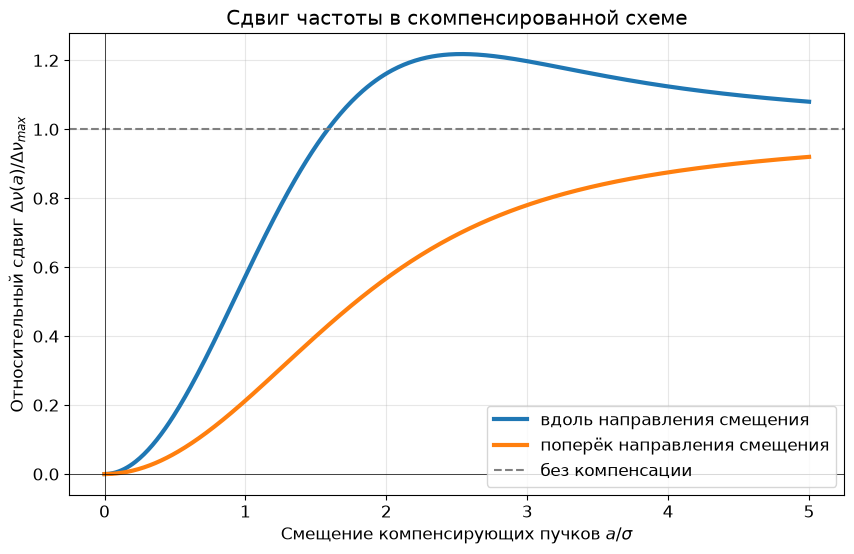

При a = sigma: вдоль смещения 0.58, поперёк 0.21
Максимум вдоль смещения 1.22 при a = 2.54 sigma


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Настройка графиков
%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

def form_factor_parallel(a_over_sigma):
    '''Форм-фактор градиента вдоль направления смещения: F'(a) / F'(0), u = a^2 / (2 sigma^2).'''
    u = np.asarray(a_over_sigma, dtype=float)**2 / 2.0
    with np.errstate(divide='ignore', invalid='ignore'):
        phi = (np.exp(-u) * (2 * u + 1) - 1) / u
    return np.where(u < 1e-10, 1.0, phi)

def form_factor_perp(a_over_sigma):
    '''Форм-фактор градиента поперёк направления смещения: F(a) / (a F'(0)).'''
    u = np.asarray(a_over_sigma, dtype=float)**2 / 2.0
    with np.errstate(divide='ignore', invalid='ignore'):
        phi = (1 - np.exp(-u)) / u
    return np.where(u < 1e-10, 1.0, phi)

# Диапазон смещений a / sigma от 0 до 5
a = np.linspace(0, 5, 500)
shift_parallel = 1.0 - form_factor_parallel(a)
shift_perp = 1.0 - form_factor_perp(a)

# Визуализация
plt.figure(figsize=(10, 6))
plt.plot(a, shift_parallel, linewidth=3, color='tab:blue', label='вдоль направления смещения')
plt.plot(a, shift_perp, linewidth=3, color='tab:orange', label='поперёк направления смещения')

plt.axhline(0, color='black', linewidth=0.5)
plt.axhline(1, color='gray', linestyle='--', label='без компенсации')
plt.axvline(0, color='black', linewidth=0.5)

plt.title('Сдвиг частоты в скомпенсированной схеме')
plt.xlabel(r'Смещение компенсирующих пучков $a / \sigma$')
plt.ylabel(r'Относительный сдвиг $\Delta \nu(a) / \Delta \nu_{max}$')

plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()

i_max = np.argmax(shift_parallel)
print(f"При a = sigma: вдоль смещения {shift_parallel[np.argmin(abs(a - 1))]:.2f}, поперёк {shift_perp[np.argmin(abs(a - 1))]:.2f}")
print(f"Максимум вдоль смещения {shift_parallel[i_max]:.2f} при a = {a[i_max]:.2f} sigma")

## Итоги

В первом порядке теории возмущений сдвиг частоты в скомпенсированной схеме определяется разностью градиентов силы центрального и компенсирующих пучков на орбите и при $a = 0$ равен нулю.
Уже при смещении $a = \sigma$ нескомпенсированная доля сдвига вдоль направления смещения составляет около $57\%$, а поперёк него около $21\%$, так что компенсация требует совмещения пучков с точностью до малой доли их размера.
Вдоль направления смещения сдвиг проходит через максимум около $1.2 \, \Delta \nu_{max}$ при $a \approx 2.5\sigma$, а поперёк него монотонно стремится к $\Delta \nu_{max}$.